# Satellite Damage Assessment: Rich Feature Extraction

## Notebook 2b - Scene-Level Feature Enrichment

This notebook sits between Notebook 2 and Notebook 3. It:
1. Loads the existing train/val/test split CSVs from Notebook 2
2. Goes back to the raw `.npy` scene files to extract richer features
3. Adds texture (GLCM), spatial variance, band statistics, and change proxies
4. Overwrites the split CSVs so Notebook 3 automatically benefits

No patches are used — everything stays at scene level.

## 1. Setup & Load Splits

In [3]:
import sys
!del /f /q "C:\Python312\Lib\site-packages\~ip*"

In [6]:
!{sys.executable} -m pip install scikit-image --user

  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
Using cached lazy_loader-0.5-py3-none-any.whl (8.0 kB)



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

from skimage.feature import graycomatrix, graycoprops
from scipy import stats

print("="*70)
print("RICH FEATURE EXTRACTION")
print("="*70)

# ── Load existing splits ─────────────────────────────────────────────────
df_train = pd.read_csv('../data/splits/train_metadata.csv')
df_val   = pd.read_csv('../data/splits/val_metadata.csv')
df_test  = pd.read_csv('../data/splits/test_metadata.csv')

print(f"\nLoaded splits:")
print(f"  Train: {len(df_train)} scenes")
print(f"  Val:   {len(df_val)} scenes")
print(f"  Test:  {len(df_test)} scenes")
print(f"\nExisting columns ({df_train.shape[1]}):")
print(df_train.columns.tolist())
print(f"\nSample row:")
print(df_train.iloc[0])

PATCH_MODE_DETECTED = 'patch_row' in df_train.columns

if PATCH_MODE_DETECTED:
    raise RuntimeError(
        "⚠ Notebook 2b detected PATCH MODE splits.\n"
        "  2b enriches at SCENE level and requires USE_PATCHES=False in Notebook 2.\n"
        "  Steps:\n"
        "    1. Set USE_PATCHES=False in Notebook 2 and re-run it\n"
        "    2. Run Notebook 2b\n"
        "    3. Set USE_PATCHES=True in Notebook 2 and re-run if you want patches\n"
        "       (Note: 2b enrichment won't carry over to patch mode)"
    )

RICH FEATURE EXTRACTION

Loaded splits:
  Train: 6 scenes
  Val:   2 scenes
  Test:  4 scenes

Existing columns (27):
['patch_id', 'city', 'period', 'year', 'damage_label', 'damage_score', 'filename', 'temporal_res', 'ndvi_mean', 'ndvi_std', 'ndvi_min', 'ndvi_max', 'ndbi_mean', 'ndbi_std', 'ndbi_min', 'ndbi_max', 'bsi_mean', 'bsi_std', 'bsi_min', 'bsi_max', 'scene_ndvi_mean', 'scene_ndvi_std', 'scene_ndbi_mean', 'scene_ndbi_std', 'scene_bsi_mean', 'scene_bsi_std', 'scene_damage_score']

Sample row:
patch_id                                                     1
city                                                   Bakhmut
period                                             2022_annual
year                                                      2022
damage_label                                                 1
damage_score                                          0.013326
filename              ../data/raw/S2_2022_Q2_Bakhmut_clean.npy
temporal_res                                           

## 2. Define Feature Extraction Functions

In [9]:
# ── Spectral index helpers ────────────────────────────────────────────────
def compute_ndvi(image):
    red = image[..., 2].astype(float)
    nir = image[..., 3].astype(float)
    return (nir - red) / (nir + red + 1e-8)

def compute_ndbi(image):
    swir = image[..., 4].astype(float)
    nir  = image[..., 3].astype(float)
    return (swir - nir) / (swir + nir + 1e-8)

def compute_bsi(image):
    blue = image[..., 0].astype(float)
    red  = image[..., 2].astype(float)
    nir  = image[..., 3].astype(float)
    swir = image[..., 4].astype(float)
    return (swir + red - nir - blue) / (swir + red + nir + blue + 1e-8)


# ── GLCM texture features ────────────────────────────────────────────────
def compute_glcm_features(band, levels=64):
    """
    Compute GLCM texture statistics on a 2D band.
    Quantises to `levels` grey levels first for speed.
    Returns contrast, dissimilarity, homogeneity, energy, correlation, ASM.
    """
    # Replace NaNs and quantise to uint8 range 0..levels-1
    band_clean = np.nan_to_num(band, nan=0.0)
    band_min, band_max = band_clean.min(), band_clean.max()
    if band_max - band_min < 1e-8:
        # Uniform image — all texture stats are trivial
        return {
            'glcm_contrast':     0.0,
            'glcm_dissimilarity': 0.0,
            'glcm_homogeneity':  1.0,
            'glcm_energy':       1.0,
            'glcm_correlation':  1.0,
            'glcm_asm':          1.0,
        }

    quantised = ((band_clean - band_min) / (band_max - band_min) * (levels - 1)).astype(np.uint8)

    # Subsample large images to keep runtime reasonable
    if quantised.shape[0] > 256 or quantised.shape[1] > 256:
        step = max(quantised.shape[0] // 256, quantised.shape[1] // 256, 1)
        quantised = quantised[::step, ::step]

    # GLCM over 4 directions, distance=1
    glcm = graycomatrix(quantised, distances=[1],
                        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=levels, symmetric=True, normed=True)

    return {
        'glcm_contrast':      float(graycoprops(glcm, 'contrast').mean()),
        'glcm_dissimilarity': float(graycoprops(glcm, 'dissimilarity').mean()),
        'glcm_homogeneity':   float(graycoprops(glcm, 'homogeneity').mean()),
        'glcm_energy':        float(graycoprops(glcm, 'energy').mean()),
        'glcm_correlation':   float(graycoprops(glcm, 'correlation').mean()),
        'glcm_asm':           float(graycoprops(glcm, 'ASM').mean()),
    }


# ── Quadrant spatial variance ────────────────────────────────────────────
def compute_quadrant_variance(index_map):
    """
    Split the scene into 4 quadrants and compute the std of each.
    Returns mean and std of the four quadrant stds — captures how
    unevenly damage is distributed across the scene.
    """
    h, w = index_map.shape
    mh, mw = h // 2, w // 2
    quadrants = [
        index_map[:mh, :mw],
        index_map[:mh, mw:],
        index_map[mh:, :mw],
        index_map[mh:, mw:],
    ]
    q_stds = [np.nanstd(q) for q in quadrants]
    return {
        'quadrant_std_mean': float(np.mean(q_stds)),
        'quadrant_std_std':  float(np.std(q_stds)),
    }


# ── Robust distribution features ─────────────────────────────────────────
def compute_robust_stats(arr, prefix):
    """
    IQR, skewness, kurtosis, and percentile range of a flattened index map.
    More robust to outlier pixels than min/max.
    """
    flat = arr[np.isfinite(arr)]
    if len(flat) == 0:
        return {f'{prefix}_iqr': 0.0, f'{prefix}_skew': 0.0,
                f'{prefix}_kurt': 0.0, f'{prefix}_p10': 0.0, f'{prefix}_p90': 0.0}
    return {
        f'{prefix}_iqr':  float(np.percentile(flat, 75) - np.percentile(flat, 25)),
        f'{prefix}_skew': float(stats.skew(flat)),
        f'{prefix}_kurt': float(stats.kurtosis(flat)),
        f'{prefix}_p10':  float(np.percentile(flat, 10)),
        f'{prefix}_p90':  float(np.percentile(flat, 90)),
    }


# ── Raw band statistics ───────────────────────────────────────────────────
def compute_band_stats(image):
    """
    Mean and std of the four most informative Sentinel-2 bands:
    RED (B04), NIR (B08), SWIR1 (B11), SWIR2 (B12).
    """
    band_map = {'red': 2, 'nir': 3, 'swir1': 4, 'swir2': 5}
    feats = {}
    for name, idx in band_map.items():
        b = image[..., idx].astype(float)
        b = b[np.isfinite(b)]
        feats[f'band_{name}_mean'] = float(np.nanmean(b)) if len(b) else 0.0
        feats[f'band_{name}_std']  = float(np.nanstd(b))  if len(b) else 0.0
    return feats


# ── Master function ───────────────────────────────────────────────────────
def extract_rich_features(filepath):
    """
    Load a cleaned .npy scene and return a dict of all new features.
    Returns None if the file cannot be loaded.
    """
    if not os.path.exists(filepath):
        return None

    image = np.load(filepath)

    ndvi = compute_ndvi(image)
    ndbi = compute_ndbi(image)
    bsi  = compute_bsi(image)
    nir_band = image[..., 3].astype(float)

    feats = {}

    # 1. GLCM texture on NIR band (most sensitive to surface change)
    feats.update(compute_glcm_features(nir_band))

    # 2. Quadrant spatial variance for each index
    for name, arr in [('ndvi', ndvi), ('ndbi', ndbi), ('bsi', bsi)]:
        qv = compute_quadrant_variance(arr)
        feats[f'{name}_quad_std_mean'] = qv['quadrant_std_mean']
        feats[f'{name}_quad_std_std']  = qv['quadrant_std_std']

    # 3. Robust distribution stats for each index
    feats.update(compute_robust_stats(ndvi, 'ndvi'))
    feats.update(compute_robust_stats(ndbi, 'ndbi'))
    feats.update(compute_robust_stats(bsi,  'bsi'))

    # 4. Raw band statistics
    feats.update(compute_band_stats(image))

    # 5. Damage score  (already in nb2 but added here as an explicit feature)
    ndvi_mean = np.nanmean(ndvi)
    ndbi_mean = np.nanmean(ndbi)
    feats['damage_score']         = float((1 - ndvi_mean) * ndbi_mean)
    feats['ndvi_ndbi_ratio']      = float(ndvi_mean / (ndbi_mean + 1e-8))
    feats['vegetation_loss_proxy'] = float(max(0.0, 0.5 - ndvi_mean))  # how far below healthy NDVI

    return feats


print("✓ All feature extraction functions defined")
print(f"\nFeatures that will be added per scene:")
print("  GLCM texture (NIR):     6  features  [contrast, dissimilarity, homogeneity, energy, correlation, ASM]")
print("  Quadrant variance:      6  features  [ndvi/ndbi/bsi × quad_std_mean/std]")
print("  Robust index stats:     15 features  [ndvi/ndbi/bsi × iqr/skew/kurt/p10/p90]")
print("  Raw band stats:         8  features  [red/nir/swir1/swir2 × mean/std]")
print("  Damage composites:      3  features  [damage_score, ndvi_ndbi_ratio, vegetation_loss_proxy]")
print("  ─────────────────────────────────────────")
print("  Total new features:     38")

✓ All feature extraction functions defined

Features that will be added per scene:
  GLCM texture (NIR):     6  features  [contrast, dissimilarity, homogeneity, energy, correlation, ASM]
  Quadrant variance:      6  features  [ndvi/ndbi/bsi × quad_std_mean/std]
  Robust index stats:     15 features  [ndvi/ndbi/bsi × iqr/skew/kurt/p10/p90]
  Raw band stats:         8  features  [red/nir/swir1/swir2 × mean/std]
  Damage composites:      3  features  [damage_score, ndvi_ndbi_ratio, vegetation_loss_proxy]
  ─────────────────────────────────────────
  Total new features:     38


## 3. Resolve Scene File Paths

In [10]:
import glob

print("=" * 70)
print("Resolving .npy file paths for each scene")
print("=" * 70)

df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
df_all['_split'] = (
    ['train'] * len(df_train) +
    ['val']   * len(df_val)   +
    ['test']  * len(df_test)
)

# Use an existing path column if notebook 2 already recorded one
if 'cleaned_filename' in df_all.columns:
    df_all['_scene_path'] = df_all['cleaned_filename']
    print("Using 'cleaned_filename' column from splits.")
elif 'filename' in df_all.columns:
    df_all['_scene_path'] = df_all['filename']
    print("Using 'filename' column from splits.")
else:
    # Scan ../data/raw/ once and build a (city, period) → path lookup.
    # Handles any naming variant without calling os.path.exists() per row.
    known_cities = df_all['city'].unique().tolist()
    scene_lookup = {}

    for path in glob.glob('../data/raw/S2_*_clean.npy'):
        fname = os.path.basename(path)   # e.g. S2_2021_Q1_Mariupol_clean.npy
        stem  = fname[3:-10]             # strip 'S2_' prefix and '_clean.npy' suffix
        for city_name in known_cities:
            if stem.endswith(f'_{city_name}'):
                period_name = stem[:-(len(city_name) + 1)]
                scene_lookup[(city_name, period_name)] = path
                break

    df_all['_scene_path'] = df_all.apply(
        lambda r: scene_lookup.get((r['city'], r['period'])), axis=1
    )
    print(f"Scanned ../data/raw/ — found {len(scene_lookup)} scene files.")

found   = df_all['_scene_path'].notna().sum()
missing = df_all['_scene_path'].isna().sum()
print(f"\n  Scenes found  : {found}")
print(f"  Scenes missing: {missing}")

if missing > 0:
    missing_scenes = (
        df_all[df_all['_scene_path'].isna()][['city', 'period']]
        .drop_duplicates()
    )
    print(f"\n  {len(missing_scenes)} unique (city, period) combos not found:")
    print(missing_scenes.to_string(index=False))
    if not glob.glob('../data/raw/S2_*_clean.npy'):
        print("\n  No scene files found at all in ../data/raw/")
        print("  → Run Notebook 1 fully before running this notebook.")
    else:
        print("\n  Some scenes missing — check period/city values match Notebook 1 output.")

Resolving .npy file paths for each scene
Using 'filename' column from splits.

  Scenes found  : 12
  Scenes missing: 0


## 4. Extract Rich Features for All Scenes

In [11]:
print("="*70)
print("Extracting rich features (this may take a few minutes)...")
print("="*70)

rich_records = []
success_count = 0
skip_count    = 0

# Deduplicate: each unique scene only needs to be processed once
# (patches from nb2 create multiple rows per scene — but here we work at scene level)
unique_scenes = df_all[['city', 'period', '_scene_path']].drop_duplicates(
    subset=['city', 'period']
).reset_index(drop=True)

print(f"\nUnique scenes to process: {len(unique_scenes)}\n")

scene_feature_cache = {}  # city+period → feature dict

for _, scene_row in unique_scenes.iterrows():
    key      = (scene_row['city'], scene_row['period'])
    filepath = scene_row['_scene_path']

    if pd.isna(filepath) or filepath is None:
        print(f"  ⚠ SKIP  {scene_row['city']:10} {scene_row['period']} — no file")
        scene_feature_cache[key] = None
        skip_count += 1
        continue

    try:
        feats = extract_rich_features(filepath)
        if feats is None:
            print(f"  ⚠ SKIP  {scene_row['city']:10} {scene_row['period']} — file not found")
            scene_feature_cache[key] = None
            skip_count += 1
        else:
            scene_feature_cache[key] = feats
            success_count += 1
            print(f"  ✓ OK    {scene_row['city']:10} {scene_row['period']}")
    except Exception as e:
        print(f"  ✗ ERROR {scene_row['city']:10} {scene_row['period']} — {str(e)[:60]}")
        scene_feature_cache[key] = None
        skip_count += 1

print(f"\n{'─'*50}")
print(f"Processed: {success_count} scenes  |  Skipped: {skip_count} scenes")

Extracting rich features (this may take a few minutes)...

Unique scenes to process: 12

  ✓ OK    Bakhmut    2022_annual
  ✓ OK    Bakhmut    2024_annual
  ✓ OK    Kharkiv    2021_annual
  ✓ OK    Kharkiv    2022_annual
  ✓ OK    Kharkiv    2024_annual
  ✓ OK    Mariupol   2024_annual
  ✓ OK    Bakhmut    2023_annual
  ✓ OK    Kharkiv    2023_annual
  ✓ OK    Bakhmut    2021_annual
  ✓ OK    Mariupol   2021_annual
  ✓ OK    Mariupol   2022_annual
  ✓ OK    Mariupol   2023_annual

──────────────────────────────────────────────────
Processed: 12 scenes  |  Skipped: 0 scenes


## 5. Merge Features Back into Splits

In [12]:
print("="*70)
print("Merging features into split DataFrames")
print("="*70)

def enrich_split(df):
    """
    For each row in a split DataFrame, look up the pre-computed
    rich features by (city, period) and append them as new columns.
    """
    new_cols = []
    for _, row in df.iterrows():
        key   = (row['city'], row['period'])
        feats = scene_feature_cache.get(key)
        new_cols.append(feats if feats else {})

    feat_df   = pd.DataFrame(new_cols, index=df.index)
    df_merged = pd.concat([df.reset_index(drop=True),
                           feat_df.reset_index(drop=True)], axis=1)
    return df_merged


df_train_rich = enrich_split(df_train)
df_val_rich   = enrich_split(df_val)
df_test_rich  = enrich_split(df_test)

# Count new columns added
new_col_count = df_train_rich.shape[1] - df_train.shape[1]
new_col_names = [c for c in df_train_rich.columns if c not in df_train.columns]

print(f"\nColumns before enrichment: {df_train.shape[1]}")
print(f"Columns after enrichment:  {df_train_rich.shape[1]}")
print(f"New features added:        {new_col_count}")
print(f"\nNew feature names:")
for i, col in enumerate(new_col_names, 1):
    print(f"  {i:2d}. {col}")

# Check for NaN rows (scenes that couldn't be processed)
nan_rows = df_train_rich[new_col_names].isna().all(axis=1).sum()
print(f"\nRows with all-NaN new features (train): {nan_rows}")
if nan_rows > 0:
    print("  These rows had missing .npy files — they will still train on original features.")

Merging features into split DataFrames

Columns before enrichment: 27
Columns after enrichment:  65
New features added:        38

New feature names:
   1. glcm_contrast
   2. glcm_dissimilarity
   3. glcm_homogeneity
   4. glcm_energy
   5. glcm_correlation
   6. glcm_asm
   7. ndvi_quad_std_mean
   8. ndvi_quad_std_std
   9. ndbi_quad_std_mean
  10. ndbi_quad_std_std
  11. bsi_quad_std_mean
  12. bsi_quad_std_std
  13. ndvi_iqr
  14. ndvi_skew
  15. ndvi_kurt
  16. ndvi_p10
  17. ndvi_p90
  18. ndbi_iqr
  19. ndbi_skew
  20. ndbi_kurt
  21. ndbi_p10
  22. ndbi_p90
  23. bsi_iqr
  24. bsi_skew
  25. bsi_kurt
  26. bsi_p10
  27. bsi_p90
  28. band_red_mean
  29. band_red_std
  30. band_nir_mean
  31. band_nir_std
  32. band_swir1_mean
  33. band_swir1_std
  34. band_swir2_mean
  35. band_swir2_std
  36. ndvi_ndbi_ratio
  37. vegetation_loss_proxy

Rows with all-NaN new features (train): 0


## 6. Feature Quality Check

In [13]:
print("="*70)
print("Feature Quality Check")
print("="*70)

df_all_rich = pd.concat([df_train_rich, df_val_rich, df_test_rich], ignore_index=True)

print(f"\nNew feature statistics (full dataset):")
print(df_all_rich[new_col_names].describe().round(4).to_string())

# Check for any constant columns (no variance = useless for ML)
constant_cols = [c for c in new_col_names
                 if df_all_rich[c].dropna().std() < 1e-8]
if constant_cols:
    print(f"\n⚠ Constant columns (will be dropped): {constant_cols}")
    df_train_rich.drop(columns=constant_cols, inplace=True)
    df_val_rich.drop(columns=constant_cols,   inplace=True)
    df_test_rich.drop(columns=constant_cols,  inplace=True)
    new_col_names = [c for c in new_col_names if c not in constant_cols]
    print(f"  Dropped {len(constant_cols)} constant columns.")
else:
    print(f"\n✓ No constant columns — all {len(new_col_names)} features have variance.")

# NaN summary
nan_summary = df_all_rich[new_col_names].isna().sum()
if nan_summary.sum() > 0:
    print(f"\nNaN counts per feature:")
    print(nan_summary[nan_summary > 0])
    print("\nFilling NaNs with column median...")
    for col in new_col_names:
        med = df_train_rich[col].median()
        df_train_rich[col].fillna(med, inplace=True)
        df_val_rich[col].fillna(med,   inplace=True)
        df_test_rich[col].fillna(med,  inplace=True)
    print("✓ NaNs filled.")
else:
    print("✓ No NaN values in new features.")

Feature Quality Check

New feature statistics (full dataset):
       glcm_contrast  glcm_dissimilarity  glcm_homogeneity  glcm_energy  glcm_correlation  glcm_asm  ndvi_quad_std_mean  ndvi_quad_std_std  ndbi_quad_std_mean  ndbi_quad_std_std  bsi_quad_std_mean  bsi_quad_std_std  ndvi_iqr  ndvi_skew  ndvi_kurt  ndvi_p10  ndvi_p90  ndbi_iqr  ndbi_skew  ndbi_kurt  ndbi_p10  ndbi_p90  bsi_iqr  bsi_skew  bsi_kurt  bsi_p10  bsi_p90  band_red_mean  band_red_std  band_nir_mean  band_nir_std  band_swir1_mean  band_swir1_std  band_swir2_mean  band_swir2_std  ndvi_ndbi_ratio  vegetation_loss_proxy
count        12.0000             12.0000           12.0000      12.0000           12.0000   12.0000              8.0000             8.0000              8.0000             8.0000             8.0000            8.0000   12.0000    12.0000    12.0000   12.0000   12.0000   12.0000    12.0000    12.0000   12.0000   12.0000  12.0000   12.0000   12.0000  12.0000  12.0000        12.0000       12.0000        12.000

## 7. Feature Importance Preview

Feature Importance Preview (Random Forest, all features)
Feature columns selected for RF preview: 56

Top 20 features by importance:
           feature  importance
          bsi_skew    0.062500
           bsi_p10    0.062500
   band_swir1_mean    0.062500
          ndvi_p10    0.062500
         ndbi_skew    0.046875
           bsi_iqr    0.046875
         ndvi_mean    0.031250
    scene_ndbi_std    0.031250
         ndvi_kurt    0.031250
 bsi_quad_std_mean    0.031250
    scene_ndvi_std    0.031250
     glcm_contrast    0.031250
    scene_bsi_mean    0.031250
           bsi_p90    0.031250
   ndvi_ndbi_ratio    0.031250
          ndbi_p90    0.031250
           bsi_std    0.031250
  glcm_correlation    0.015625
glcm_dissimilarity    0.015625
   scene_ndvi_mean    0.015625


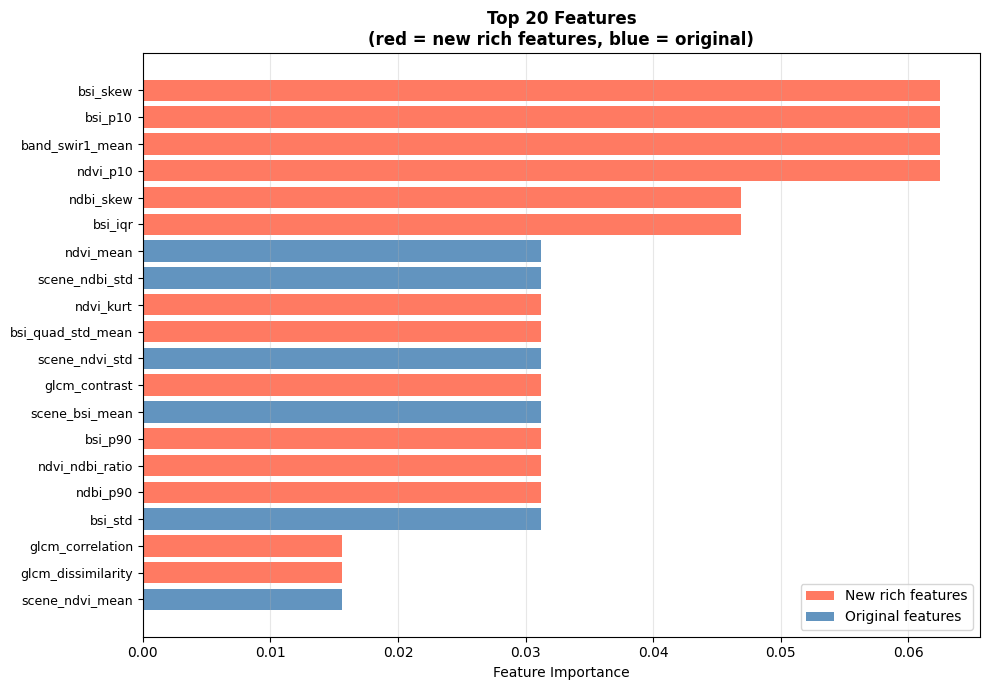


✓ Saved ../results/plots/rich_feature_importance.png


In [14]:
print("="*70)
print("Feature Importance Preview (Random Forest, all features)")
print("="*70)

from sklearn.ensemble import RandomForestClassifier

# Derive feature columns directly from the enriched DataFrame:
# use all numeric columns except metadata and the label.
exclude = {'damage_label', 'patch_id', 'city', 'period', 'year', 'quarter',
           'filename', 'cleaned_filename', '_scene_path', '_split',
           'cloud_cover_pct', 'valid_pixels_pct', 'scene_id', 'damage_score'}
all_feature_cols = [
    c for c in df_train_rich.columns
    if c not in exclude
    and pd.api.types.is_numeric_dtype(df_train_rich[c])
    and c != 'damage_label'
]

print(f"Feature columns selected for RF preview: {len(all_feature_cols)}")

X = df_train_rich[all_feature_cols].fillna(0).values
y = df_train_rich['damage_label'].values

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'feature':    all_feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 20 features by importance:")
print(importance_df.head(20).to_string(index=False))

# Visualise
top20 = importance_df.head(20)
colors = ['tomato' if c in new_col_names else 'steelblue'
          for c in top20['feature']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(top20)), top20['importance'].values, color=colors, alpha=0.85)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['feature'].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance')
ax.set_title('Top 20 Features\n(red = new rich features, blue = original)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='tomato',    alpha=0.85, label='New rich features'),
                   Patch(facecolor='steelblue', alpha=0.85, label='Original features')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../results/plots/rich_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Saved ../results/plots/rich_feature_importance.png")

## 8. Damage vs Undamaged Distribution for New Features

Distribution Check: Damaged vs Not Damaged


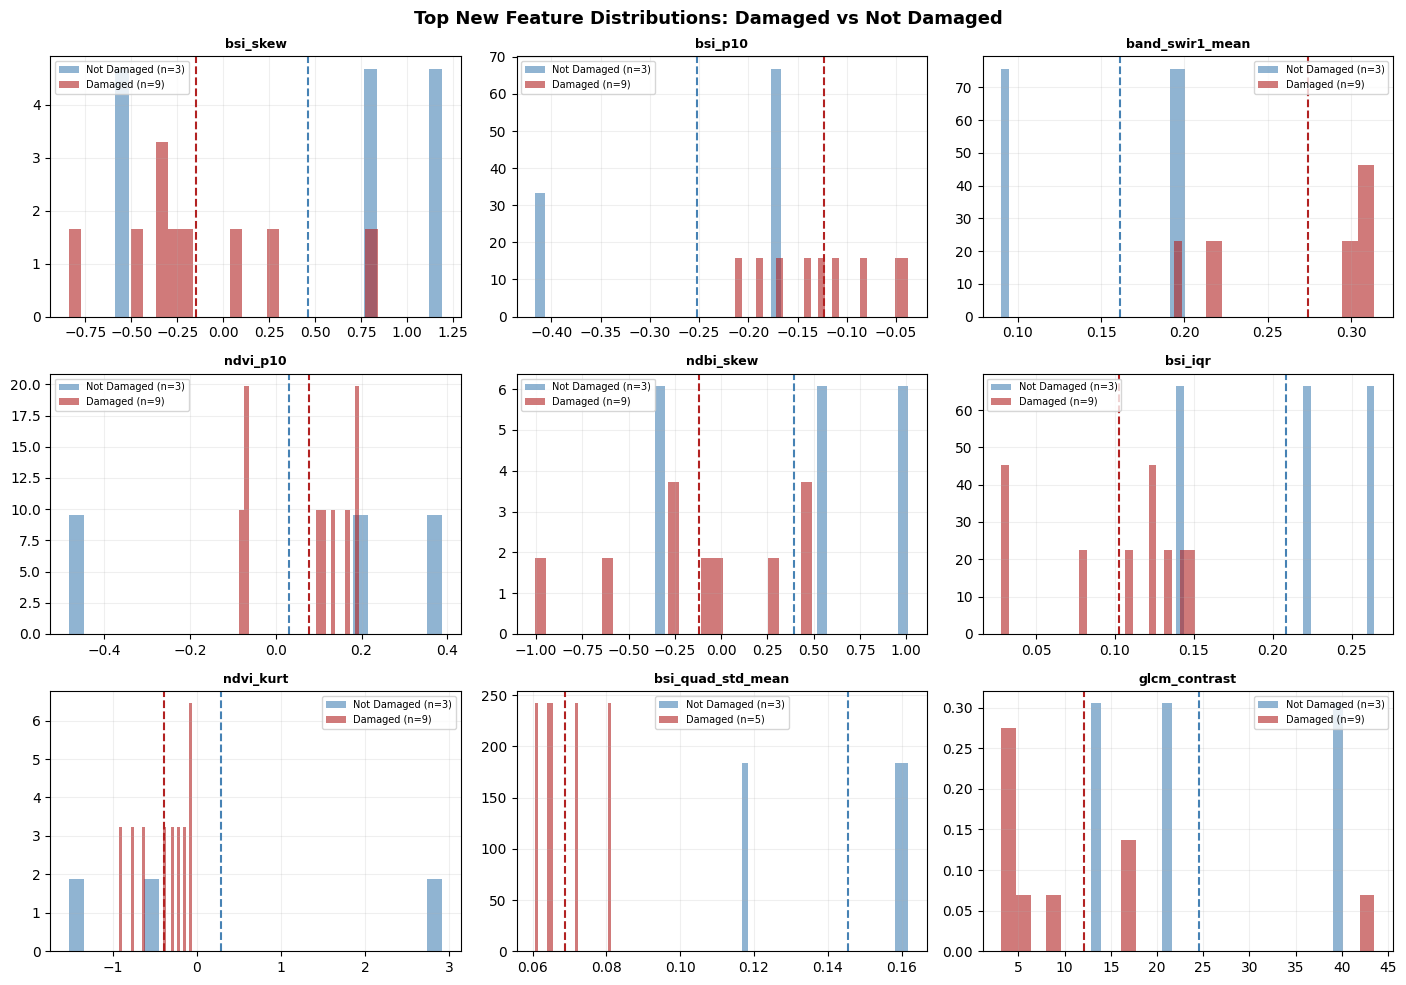


✓ Saved ../results/plots/rich_feature_distributions.png


In [15]:
print("="*70)
print("Distribution Check: Damaged vs Not Damaged")
print("="*70)

# Pick the top 9 new features by importance for the plot
top_new = [c for c in importance_df['feature'] if c in new_col_names][:9]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for ax, feat in zip(axes, top_new):
    dam     = df_all_rich[df_all_rich['damage_label'] == 1][feat].dropna()
    not_dam = df_all_rich[df_all_rich['damage_label'] == 0][feat].dropna()

    ax.hist(not_dam, bins=25, alpha=0.6, color='steelblue', density=True,
            label=f'Not Damaged (n={len(not_dam)})')
    ax.hist(dam,     bins=25, alpha=0.6, color='firebrick', density=True,
            label=f'Damaged (n={len(dam)})')
    ax.axvline(not_dam.mean(), color='steelblue', linestyle='--', linewidth=1.5)
    ax.axvline(dam.mean(),     color='firebrick',  linestyle='--', linewidth=1.5)
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2)

plt.suptitle('Top New Feature Distributions: Damaged vs Not Damaged',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/rich_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Saved ../results/plots/rich_feature_distributions.png")

## 9. Save Enriched Splits

In [16]:
print("="*70)
print("Saving Enriched Split CSVs")
print("="*70)

# Back up originals first
for name in ['train', 'val', 'test']:
    src = f'../data/splits/{name}_metadata.csv'
    dst = f'../data/splits/{name}_metadata_original.csv'
    if os.path.exists(src) and not os.path.exists(dst):
        import shutil
        shutil.copy(src, dst)
        print(f"  Backed up {src} → {dst}")

# Save enriched versions (overwrites the originals Notebook 3 reads)
df_train_rich.to_csv('../data/splits/train_metadata.csv', index=False)
df_val_rich.to_csv('../data/splits/val_metadata.csv',     index=False)
df_test_rich.to_csv('../data/splits/test_metadata.csv',   index=False)

print(f"\n✓ Saved ../data/splits/train_metadata.csv  ({df_train_rich.shape[1]} columns)")
print(f"✓ Saved ../data/splits/val_metadata.csv    ({df_val_rich.shape[1]} columns)")
print(f"✓ Saved ../data/splits/test_metadata.csv   ({df_test_rich.shape[1]} columns)")

print(f"\n{'='*70}")
print("FEATURE ENRICHMENT COMPLETE")
print("='*70")
print(f"\n  Original features: {df_train.shape[1]}")
print(f"  New features added: {new_col_count}")
print(f"  Total features:     {df_train_rich.shape[1]}")
print(f"\n  Original backups saved as *_metadata_original.csv")
print(f"  Enriched CSVs overwrite *_metadata.csv")
print(f"\n  → Run Notebook 3 as normal — it will automatically use the richer features.")
print(f"{'='*70}")

Saving Enriched Split CSVs
  Backed up ../data/splits/train_metadata.csv → ../data/splits/train_metadata_original.csv
  Backed up ../data/splits/val_metadata.csv → ../data/splits/val_metadata_original.csv
  Backed up ../data/splits/test_metadata.csv → ../data/splits/test_metadata_original.csv

✓ Saved ../data/splits/train_metadata.csv  (65 columns)
✓ Saved ../data/splits/val_metadata.csv    (65 columns)
✓ Saved ../data/splits/test_metadata.csv   (65 columns)

FEATURE ENRICHMENT COMPLETE
='*70

  Original features: 27
  New features added: 38
  Total features:     65

  Original backups saved as *_metadata_original.csv
  Enriched CSVs overwrite *_metadata.csv

  → Run Notebook 3 as normal — it will automatically use the richer features.
